In [4]:
import sys
from pathlib import Path

# If notebook is inside /notebooks, project root is the parent folder
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added to path:", PROJECT_ROOT)
print("cwd:", Path.cwd())

Project root added to path: C:\Users\vines\Documents\Wireless-Optimization
cwd: C:\Users\vines\Documents\Wireless-Optimization\notebooks


In [5]:
import os
import pandas as pd
from src.model import fit_linear_regression, predict_linear_regression, mean_position_error
from src.utils import split_indices, standardize_fit, standardize_apply

DATA_DIR = r"C:\Users\vines\Documents\Wireless-Optimization\data"
print("Files in data/:", os.listdir(DATA_DIR))

csv_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("No CSV found in data/. If you downloaded a zip, unzip it into data/.")

csv_path = os.path.join(DATA_DIR, csv_files[0])
print("Loading:", csv_path)

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()

Files in data/: ['.ipynb_checkpoints', 'Indoor Positioning Area.png', 'README.md', 'RSS - Kriging.csv', 'RSS - Original.csv']
Loading: C:\Users\vines\Documents\Wireless-Optimization\data\RSS - Kriging.csv
Shape: (203, 5)


,X,Y,RSS-A,RSS-B,RSS-C
0,0,2,49,73,69
1,0,3,50,70,70
2,0,4,50,68,70
3,0,5,51,68,71
4,0,6,52,67,70


In [6]:
df.columns.tolist(), df.dtypes

(['X', 'Y', 'RSS-A', 'RSS-B', 'RSS-C'],
 X        int64
 Y        int64
 RSS-A    int64
 RSS-B    int64
 RSS-C    int64
 dtype: object)

In [7]:
df.columns.tolist()
df.head(2)

,X,Y,RSS-A,RSS-B,RSS-C
0,0,2,49,73,69
1,0,3,50,70,70


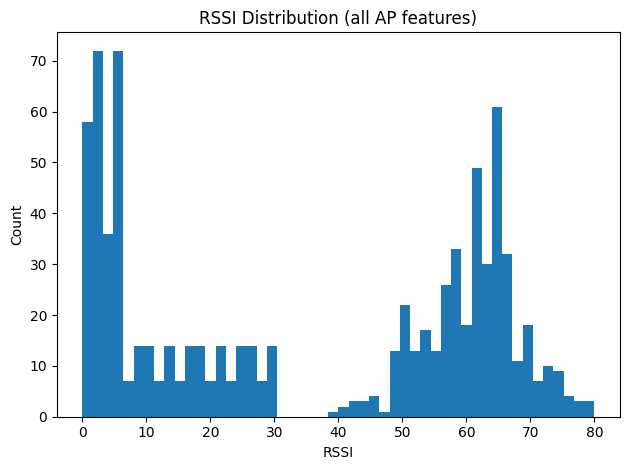

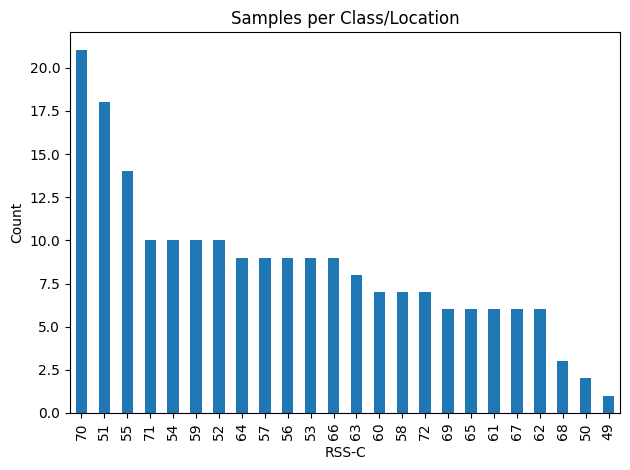

Saved figures to: C:\Users\vines\Documents\Wireless-Optimization\figures
Label column used: RSS-C
Number of RSSI features: 4


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

FIG_DIR = r"C:\Users\vines\Documents\Wireless-Optimization\figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Guess label column (adjust after you inspect df.columns)
possible_labels = ["label","Label","ROOM","Room","Location","LOCATION","Position","POSITION","Class","CLASS","zone","Zone"]
label_col = next((c for c in possible_labels if c in df.columns), df.columns[-1])

X_cols = [c for c in df.columns if c != label_col and pd.api.types.is_numeric_dtype(df[c])]

# RSSI distribution
vals = df[X_cols].to_numpy().flatten()
vals = vals[~np.isnan(vals)]
plt.figure()
plt.hist(vals, bins=50)
plt.title("RSSI Distribution (all AP features)")
plt.xlabel("RSSI")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rssi_distribution.png"))
plt.show()

# Class balance
plt.figure()
df[label_col].value_counts().plot(kind="bar")
plt.title("Samples per Class/Location")
plt.xlabel(label_col)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_counts.png"))
plt.show()

print("Saved figures to:", FIG_DIR)
print("Label column used:", label_col)
print("Number of RSSI features:", len(X_cols))

In [9]:
import numpy as np
import pandas as pd

Y_pos = df[["X", "Y"]].to_numpy(dtype=float)
feature_cols = ["RSS-A", "RSS-B", "RSS-C"]
X_feat = df[feature_cols].to_numpy(dtype=float)

In [10]:
def split_indices(n, test_size=0.2, seed=695):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    n_test = int(n * test_size)
    return idx[n_test:], idx[:n_test]

def standardize_fit(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    return mu, sigma

def standardize_apply(X, mu, sigma):
    return (X - mu) / sigma

train_idx, test_idx = split_indices(len(df), test_size=0.2, seed=695)

X_train_raw, X_test_raw = X_feat[train_idx], X_feat[test_idx]
Y_train, Y_test = Y_pos[train_idx], Y_pos[test_idx]

mu, sigma = standardize_fit(X_train_raw)
X_train = standardize_apply(X_train_raw, mu, sigma)
X_test  = standardize_apply(X_test_raw,  mu, sigma)

In [11]:
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

def fit_linear_regression(X, Y):
    Xb = add_bias(X)
    W = np.linalg.pinv(Xb) @ Y
    return W

def predict_linear_regression(X, W):
    Xb = add_bias(X)
    return Xb @ W

def mean_position_error(Y_true, Y_pred):
    d = np.sqrt(np.sum((Y_true - Y_pred) ** 2, axis=1))
    return float(np.mean(d))

In [12]:
import itertools

results = []

for r in [1, 2, 3]:
    for subset in itertools.combinations(range(3), r):
        cols = list(subset)

        W = fit_linear_regression(X_train[:, cols], Y_train)
        pred = predict_linear_regression(X_test[:, cols], W)
        err = mean_position_error(Y_test, pred)

        results.append({
            "subset": [feature_cols[i] for i in cols],
            "k": r,
            "mean_position_error": err
        })

results_df = pd.DataFrame(results).sort_values(["k", "mean_position_error"])
results_df

,subset,k,mean_position_error
2,[RSS-C],1,2.634909
1,[RSS-B],1,6.243780
0,[RSS-A],1,6.823862
4,"[RSS-A, RSS-C]",2,2.298081
5,"[RSS-B, RSS-C]",2,2.393198
3,"[RSS-A, RSS-B]",2,6.253366
6,"[RSS-A, RSS-B, RSS-C]",3,2.086718


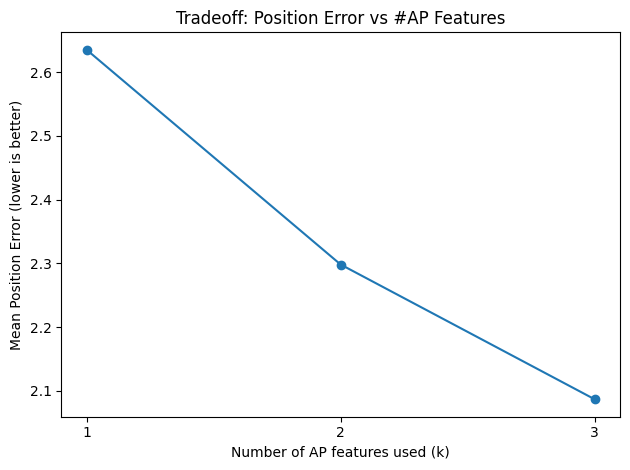

In [13]:
import matplotlib.pyplot as plt
import os

best_by_k = results_df.groupby("k").first().reset_index()
best_by_k

FIG_DIR = r"C:\Users\vines\Documents\Wireless-Optimization\figures"
os.makedirs(FIG_DIR, exist_ok=True)

curve = best_by_k.sort_values("k")

plt.figure()
plt.plot(curve["k"], curve["mean_position_error"], marker="o")
plt.xticks([1, 2, 3])
plt.xlabel("Number of AP features used (k)")
plt.ylabel("Mean Position Error (lower is better)")
plt.title("Tradeoff: Position Error vs #AP Features")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "accuracy_vs_k.png"))
plt.show()